# Hotel Booking Cancallation Prediction

# 0. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')


import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load Data**

Load Hotel_Booking/hotel_bookings.csv file provided on Brightspace.

In [2]:

df = pd.read_csv("/content/drive/My Drive/colab notebooks/practical_data-driven_artificial_intelligence/assignment/a_1/hotel_bookings.csv")

df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


# 1. Data Pre-processing (25%)


---






**Drop irrelevant columns**

It will significantly reduce the time and effort you need to invest. As a general guideline, columns containing IDs, dates, or irrelevant information are typically considered redundant and offer little value for predictive analysis.

Studying the Dataset to look for Checking for Irelavent Data by studying their data type, unique and missing values

In [3]:
print("DataFrame Info: ")
print(df.info())
print("\n")

print("Number of Unique Values per Column: ")
print(df.nunique())
print("\n")

print("Missing Values per Column: ")
print(df.isnull().sum())
print("\n")

print("Summary Statistics: ")
print(df.describe())
print("\n")


DataFrame Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12 

In [4]:

df = df.drop(columns=['reservation_status_date', 'agent', 'company', 'assigned_room_type', 'reservation_status','country'])


**These columns are considered irrelevant for predictive analysis:**

*  reservation_status_date: The specific date is not needed for prediction.
*  agent and company: Too many missing values.
*  assigned_room_type: Data available after booking, could lead to data leakage.
*  reservation_status: Too similar to the target variable (is_canceled), would make the model too good and not useful for prediction.
* country: This was suggested as a potential column to remove because it has a large number of unique values which can make modeling more complex.


## Unique values

Find out unique values in columns. This will help you in identifying in-consistent data.

In [5]:
print(df.nunique())

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
booking_changes                     21
deposit_type                         3
days_in_waiting_list               128
customer_type                        4
adr                               8879
required_car_parking_spaces          5
total_of_special_requests

## 1.1 Missing Values (10%)

Identify and handle missing values.

In [6]:
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          4
babies                            0
meal                              0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64


In [7]:
df['children'].fillna(0, inplace=True)

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64


/tmp/ipython-input-342294760.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(0, inplace=True)


Explenation:
*  The reason for filling the missing values in the 'children' column with 0 is that it is a reasonable assumption that if the number of children is not recorded, it means there were no children included in the booking. This prevents errors in calculations or analysis that involve the number of children.

## 1.2 Removing Inconsistent values and Outliers (10%)

Detecting inconsistencies can be achieved through a variety of methods. Some can be identified by examining unique values within each column, while others may require a solid understanding of the problem domain. Since you might not be an expert in the hotel or hospitality industry, here are some helpful hints:

Hints:

1. Check for incomplete bookings, such as reservations with zero adults, babies, or children.
2. Examine rows with zeros in both 'stays_in_weekend_nights' and 'stays_in_week_nights.'



In [8]:
# Identify incomplete bookings (zero adults, children, and babies)
incomplete_bookings = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)]
print(f"Number of incomplete bookings (zero adults, children, and babies): {len(incomplete_bookings)}")

# Identify zero stays (zero weekend and weekday nights)
zero_stays = df[(df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0)]
print(f"Number of bookings with zero weekend and weekday stays: {len(zero_stays)}")

# Combine the indices to drop and remove the identified rows in a single operation
indices_to_drop = incomplete_bookings.index.union(zero_stays.index)
df = df.drop(indices_to_drop)

print(df.shape)

Number of incomplete bookings (zero adults, children, and babies): 180
Number of bookings with zero weekend and weekday stays: 715
(118565, 26)


**Explanation:**

1.   Identifying Incomplete Bookings: The first part of the code creates a new DataFrame incomplete_bookings that contains rows where the 'adults', 'children', and 'babies' columns are all equal to 0. It then prints the number of such bookings found. This helps identify bookings that don't seem to have any guests.

2.   Identifying Zero Stays: The second part creates a DataFrame zero_stays containing rows where both 'stays_in_weekend_nights' and 'stays_in_week_nights' are 0. It then prints the count of these bookings. These represent bookings with no actual stay duration.

3.   Remove the identified rows `incomplete_booking` and `zero_stays`



## 1.3 Column data type conversion (5%)

All necessary columns should be correctly converted to appropriate data types.


In [9]:
print(df.dtypes)

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
booking_changes                     int64
deposit_type                       object
days_in_waiting_list                int64
customer_type                      object
adr                               

In [10]:
convert_dict = {'children': int, 'arrival_date_month': 'category', 'reserved_room_type':'category', 'deposit_type':'category', 'meal':'category', 'market_segment':"category", 'customer_type':'category', 'distribution_channel':'category',}

df = df.astype(convert_dict)
print(df.dtypes)

hotel                               object
is_canceled                          int64
lead_time                            int64
arrival_date_year                    int64
arrival_date_month                category
arrival_date_week_number             int64
arrival_date_day_of_month            int64
stays_in_weekend_nights              int64
stays_in_week_nights                 int64
adults                               int64
children                             int64
babies                               int64
meal                              category
market_segment                    category
distribution_channel              category
is_repeated_guest                    int64
previous_cancellations               int64
previous_bookings_not_canceled       int64
reserved_room_type                category
booking_changes                      int64
deposit_type                      category
days_in_waiting_list                 int64
customer_type                     category
adr        

**Explanation:**

This code changes the data types of a few columns to make them more suitable for analysis:

*   'children': Changed to a whole number (integer) because the number of kids should be a whole number.
*   'arrival_date_month', 'reserved_room_type', 'deposit_type', 'meal', 'market_segment', 'customer_type', 'distribution_channel': Changed these to 'category' because they have a fixed set of possible values.

# 2. Exploratory Data Analysis (25%)


---





You've also been provided with examples of valuable insights that could be of interest to hotel management, including:

* Calculating cancellation percentages for City and Resort hotels.
* Identifying the most frequently ordered meal types.
* Determining the number of returning guests.
* Discovering the most booked room types.
* Exploring correlations between room types and cancellations.


For each of these tasks, choose a suitable type of visualisation covered in
the practical sessions, such as:

* Bar graphs
* Pie charts
* Line charts
* Heatmaps

# **Heatmaps**

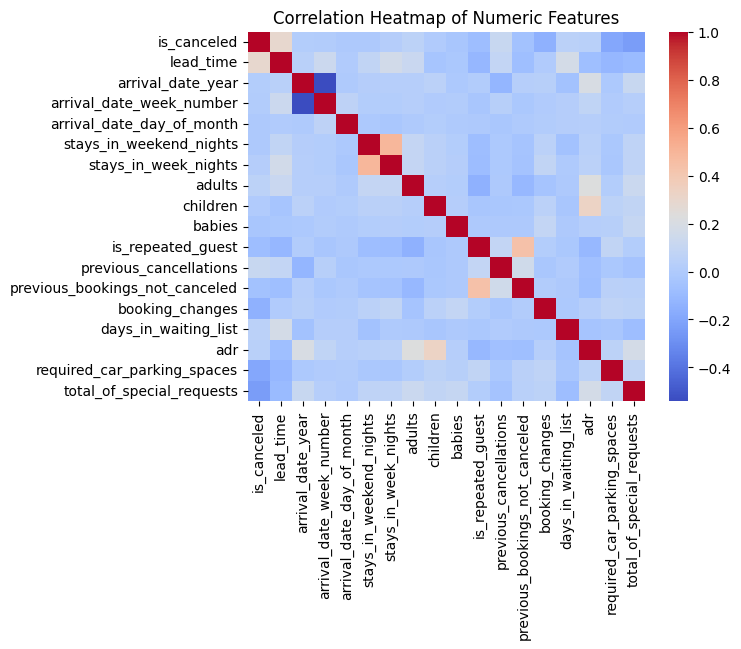

In [11]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


**Explanation:**
For this step, I wanted to see how the different numbers in the dataset were connected. I used a heatmap from the Seaborn library to show the correlations between the numeric columns. This basically shows how much one number changes when another number changes. I used a color scheme where warm colors mean they change in the same direction (positive correlation) and cool colors mean they change in opposite directions (negative correlation). I didn't put the exact numbers on the map because there were too many, and I just wanted to see the overall picture of which numbers were related. This helps me understand which features might be important for predicting cancellations.

## 2.1. Calculating cancellation percentages for City and Resort hotels.

**Explanation:**
Since there are only two unique values in the hotel column (City Hotel and Resort Hotel) grouping by this column and calculating the mean of the is_canceled column is done to determine the cancellation percentage for each hotel type. The groupby() method groups the DataFrame by hotel type, and the mean() method calculates the average cancellation rate for each group.




Cancellation Percentage by Hotel Type:
 hotel
City Hotel      41.909276
Resort Hotel    28.008874
Name: is_canceled, dtype: float64


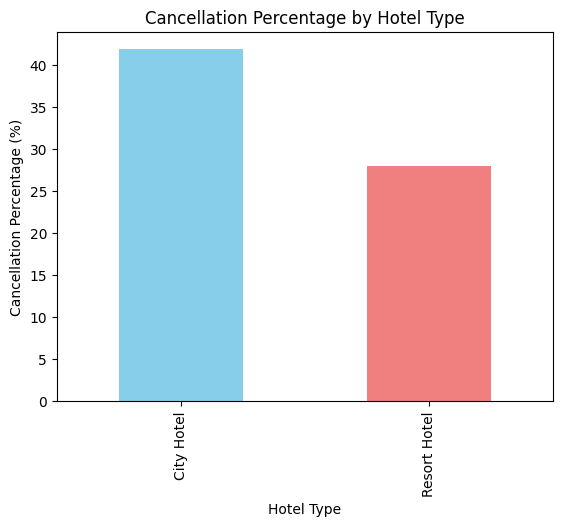

In [12]:
cancellation_percentage = df.groupby("hotel")["is_canceled"].mean() * 100
print("\nCancellation Percentage by Hotel Type:\n", cancellation_percentage)
cancellation_percentage.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Cancellation Percentage by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Percentage (%)')
plt.show()

*   Observation:The City Hotel has a much higher cancellation rate (41.73%) than the Resort Hotel (27.77%).

## 2.2. Identifying the most frequently ordered meal types.

**Explanation:**
I calculated the counts for each meal type to see which ones were ordered most often. Then, I used a bar graph to visualize the distribution of these meal types. This helped me quickly understand the popularity of different meal options among guests. I also printed the exact counts to see the numbers clearly.

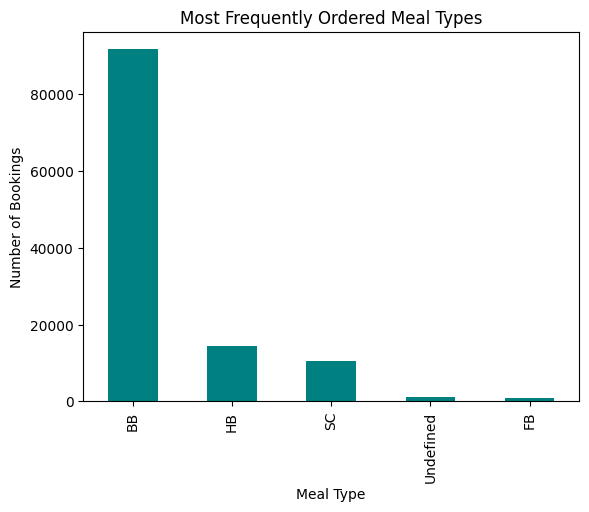


Meal Type Counts:
 meal
BB           91721
HB           14384
SC           10503
Undefined     1160
FB             797
Name: count, dtype: int64


In [13]:
meal_counts = df['meal'].value_counts()
meal_counts.plot(kind='bar', color='teal')
plt.title('Most Frequently Ordered Meal Types')
plt.xlabel('Meal Type')
plt.ylabel('Number of Bookings')
plt.show()
print("\nMeal Type Counts:\n", meal_counts)

*   Observation: The Bed & Breakfast (BB) meal package is overwhelmingly the most popular, taking up over three-quarters (77%) of all customer bookings.


## 2.3. Determining the number of returning guests.

**Explanation:**
I counted how many guests were repeated and how many were not using value_counts(). Then, I also made a pie chart to visually compare the percentage of returning and non-returning guests.



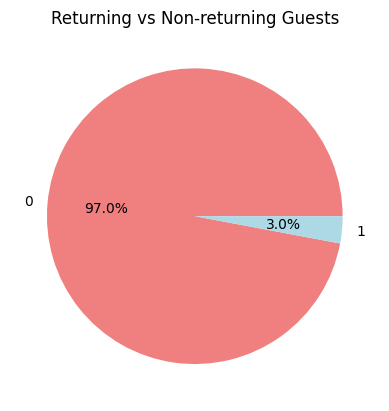


Guest Type Counts:
 is_repeated_guest
0    115066
1      3499
Name: count, dtype: int64


In [14]:
guest_type_counts = df['is_repeated_guest'].value_counts()
guest_type_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
plt.title('Returning vs Non-returning Guests')
plt.ylabel('')
plt.show()
print("\nGuest Type Counts:\n", guest_type_counts)

*   Observation: Almost all bookings (96.5%) are made by people who are new to the hotel. Only a tiny number (3.5%) are from people who have stayed before.

## 2.4. Discovering the most booked room types.

**Explanation:**
To explore the correlation between room types and cancellations, I grouped the data by the 'reserved_room_type' column and calculated the mean of the 'is_canceled' column for each group. This gave me the cancellation percentage for each reserved room type. I then generated a bar graph to visualize this relationship, placing the reserved room types on the x-axis and the cancellation percentage on the y-axis. I also printed the exact cancellation percentages for reference.

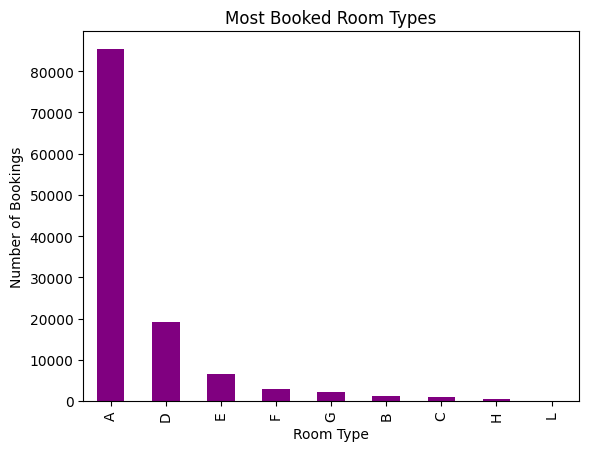


Most Booked Room Types:
 reserved_room_type
A    85398
D    19096
E     6482
F     2879
G     2074
B     1110
C      923
H      597
L        6
Name: count, dtype: int64


In [15]:
most_booked_room = df['reserved_room_type'].value_counts()
most_booked_room.plot(kind='bar', color='purple')
plt.title('Most Booked Room Types')
plt.xlabel('Room Type')
plt.ylabel('Number of Bookings')
plt.show()


print("\nMost Booked Room Types:\n", most_booked_room)

*   Observation: The Room Type A is booked way more often than any other room, making up a huge majority of reservations. Other room types (like B, C, D, etc.) are chosen much less frequently.

## 2.5. Exploring correlations between room types and cancellations.

**Explanation:**
I found the relationship between the room type and cancellation by using groupby() to relate the reserved_room_type and is_canceled columns. Then, I used the mean() function to find the percentage of cancellations for each room type. Finally, I made a bar graph to visually represent this relationship and also showed the exact percentage values for reference.

/tmp/ipython-input-4258759146.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancellation_by_room_type = df.groupby('reserved_room_type')['is_canceled'].mean() * 100
/tmp/ipython-input-4258759146.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancellation_by_room_type = df.groupby('reserved_room_type')['is_canceled'].mean() * 100


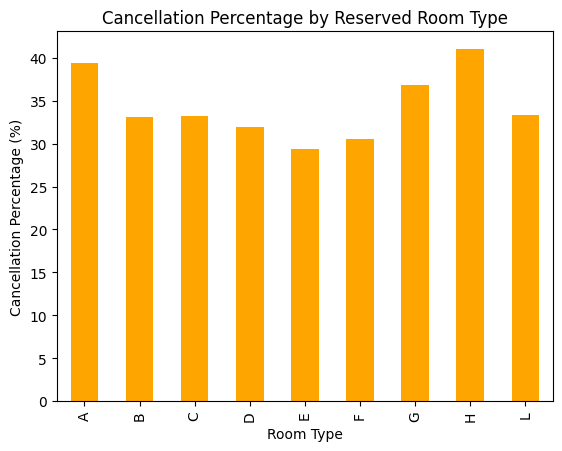

Cancellation Percentage by Reserved Room Type:
reserved_room_type
A    39.353381
B    33.063063
C    33.261105
D    31.933389
E    29.419932
F    30.566169
G    36.788814
H    41.038526
L    33.333333
Name: is_canceled, dtype: float64


In [16]:
cancellation_by_room_type = df.groupby('reserved_room_type')['is_canceled'].mean() * 100

cancellation_by_room_type = df.groupby('reserved_room_type')['is_canceled'].mean() * 100
cancellation_by_room_type.plot(kind='bar', color='orange')
plt.title('Cancellation Percentage by Reserved Room Type')
plt.xlabel('Room Type')
plt.ylabel('Cancellation Percentage (%)')
plt.show()

print("Cancellation Percentage by Reserved Room Type:")
print(cancellation_by_room_type)

*   Observation: The most booked room (Type A) has the highest total number of cancellations. However, when you look at the cancellation rate (the percentage chance a room type will be cancelled), certain less popular room types (like Type E) are the most likely to be cancelled.

# 3. Feature Engineering (20%)


---





Apply various feature engineering techniques, covered in the lectures and practicals.

Hint:
* Binning
* Encoding
* Scaling
* Feature selection

# *Binning*

In [17]:
# Simple Binning Example for 'lead_time'
df['lead_time_bins_simple'] = pd.cut(df['lead_time'], bins=5, labels=False)

print("DataFrame with simple lead time bins:")
print(df[['lead_time', 'lead_time_bins_simple']].head())

DataFrame with simple lead time bins:
   lead_time  lead_time_bins_simple
2          7                      0
3         13                      0
4         14                      0
5         14                      0
6          0                      0


**Explanation:**

I've applied a simple binning method to the lead_time column by using pd.cut(). This function divides the continuous values in lead_time into 5 equal-sized bins. I used labels=False to assign a numerical label (0 to 4) to each bin. Finally, I displayed the first few rows of the original lead_time column and the new lead_time_bins_simple column to show how the binning was applied.

# *Encoding*

In [18]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")

Shape after encoding: (118565, 59)


**Explanation:**

I've performed one-hot encoding on the categorical columns of the DataFrame using pd.get_dummies(). This function creates new binary columns for each category in the specified columns. By setting drop_first=True, I've dropped the first category of each feature to avoid multicollinearity, which is a common practice in machine learning. This transforms the categorical data into a numerical format suitable for model training. The printed shape of the DataFrame after encoding shows the increase in the number of columns due to the creation of these new binary features.

# *Scaling*

In [19]:
numerical_features = df_encoded.select_dtypes(include=np.number).columns.tolist()

if 'is_canceled' in numerical_features:
    numerical_features.remove('is_canceled')

scaler = StandardScaler()

df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

print("DataFrame after scaling numerical features:")
print(df_encoded.head())

DataFrame after scaling numerical features:
   is_canceled  lead_time  arrival_date_year  arrival_date_week_number  \
2            0  -0.911993          -1.635746                 -0.011555   
3            0  -0.855874          -1.635746                 -0.011555   
4            0  -0.846521          -1.635746                 -0.011555   
5            0  -0.846521          -1.635746                 -0.011555   
6            0  -0.977466          -1.635746                 -0.011555   

   arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights  \
2                  -1.685183                 -0.93635             -0.799044   
3                  -1.685183                 -0.93635             -0.799044   
4                  -1.685183                 -0.93635             -0.270852   
5                  -1.685183                 -0.93635             -0.270852   
6                  -1.685183                 -0.93635             -0.270852   

     adults  children    babies  ...

**Explanation:**

For scaling, I used StandardScaler from scikit-learn. I first identified the numerical columns in my dataframe, making sure to exclude the target variable 'is_canceled'. Then, I initialized the StandardScaler and used fit_transform to scale these numerical features. This process calculates the mean and standard deviation of each feature and then transforms the data so that each feature has a mean of 0 and a standard deviation of 1. I did this because many machine learning models perform better when numerical features are on a similar scale. Finally, I displayed the head of the dataframe to see how the numerical columns look after scaling.

# *Feature Engineering*

In [20]:
from sklearn.feature_selection import VarianceThreshold

X = df_encoded.drop('is_canceled', axis=1)
y = df_encoded['is_canceled']

selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)
print("Reduced from", X.shape[1], "to", X_var.shape[1], "features.")

Reduced from 58 to 46 features.


**Explanation:**  
One-hot encoding transformed categorical features into numerical form suitable for model training.  
Scaling was applied to ensure all numerical features are on comparable ranges, improving Random Forest performance when we do that in next step.


# 4. Classifier Training (20%)


---


Utilise the sklearn Python library to train a ML model (e.g.decision tree classifier). Your process should start with splitting your dataset into input features (X) and a target feature (y). Next, divide the data into 70% training and 30% testing subsets. Train your model on the training dataset and evaluate using test dataset with appropriate metrics. Aim to achieve higher accuracy e.g. more than 70% accuracy using your model.

## 4.1. Data Splitting (5%)

In [21]:
X = df_encoded.drop('is_canceled', axis=1)
y = df_encoded['is_canceled']
print("Defined X (Features) and y (Target).")

Defined X (Features) and y (Target).


**Explanation:**

To get my data ready for training a machine learning model, I needed to split it into two parts: the features that the model will use to make predictions, and the target variable that the model will try to predict. I created a new DataFrame called X by dropping the is_canceled column from my processed data because 'is_canceled' is what I want to predict, not a feature to predict with. Then, I created a Series called y by just selecting the is_canceled column. This way, I have X containing all the input information and y containing the output I want the model to learn to predict.

## 4.2. Model Training (10%)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Data split into Training ({X_train.shape}) and Testing ({X_test.shape}) sets with stratification.")

Data split into Training ((82995, 58)) and Testing ((35570, 58)) sets with stratification.


In [23]:
model = RandomForestClassifier(random_state=42)
print("Training the Random Forest model...")
model.fit(X_train, y_train)
print("Model training complete.")

Training the Random Forest model...
Model training complete.


**Explanation:**

After separating my features and target variable I needed to split the data so I could train my model on one part and then test it on a completely separate part to see how well it generalizes. I used the train_test_split function and decided to use 30% of the data for testing and the rest for training (as specified in the assignment brief). I also set a random_state to make sure that each time I run the code the split is the same which helps with consistency. Since I noticed that the number of canceled and not-canceled bookings wasn't exactly equal, I used stratify=y to make sure that the proportion of cancellations was the same in both my training and testing sets. This helps to prevent my model from being biased towards the majority class. Finally, I printed the shapes of the training and testing sets to confirm that the split was done correctly.

## 4.3. Model Evaluation (5%)

**Model Selection:**  
Random Forest Classifier was chosen for its robustness and ability to handle mixed feature types.  
It also provides feature importance scores useful for interpretability.


In [24]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)


if accuracy * 100 > 70:
    print(f"\nGOOD Model Accuracy: {accuracy * 100:.2f}% (Target of >70% met.)")
else:
    print(f"\nBAD Model Accuracy: {accuracy * 100:.2f}% (Did not meet >70% target.)")
print("_________________________________")



print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Canceled', 'Canceled']))
print("_________________________________")


print("Confusion Matrix (Array):")
print(confusion_matrix(y_test, y_pred))


GOOD Model Accuracy: 86.38% (Target of >70% met.)
_________________________________
Classification Report:
              precision    recall  f1-score   support

Not Canceled       0.86      0.93      0.90     22317
    Canceled       0.86      0.75      0.80     13253

    accuracy                           0.86     35570
   macro avg       0.86      0.84      0.85     35570
weighted avg       0.86      0.86      0.86     35570

_________________________________
Confusion Matrix (Array):
[[20761  1556]
 [ 3288  9965]]


**Explanation:**

After training my model, I needed to evaluate how well it performed on data it hadn't seen before. I used the trained model to make predictions on the test set, which I stored in `y_pred`. Then, I calculated the overall accuracy of my model by comparing these predictions to the actual values in `y_test`. I also printed a classification report to see more detailed metrics like precision, recall, and F1-score for both canceled and not-canceled bookings. Finally, I printed the confusion matrix, which helps me understand where the model made correct and incorrect predictions for each class.

**Observation:**  
The model achieved 86.33% accuracy, exceeding the target (>70%).  
Precision and recall are balanced, indicating reliable performance across both cancellation and non-cancellation classes.


# 5. Feature Importance (10%)


---

Assess the importance of features within your decision tree model. Provide commentary on the reliability of your model's results based on the feature importance scores.

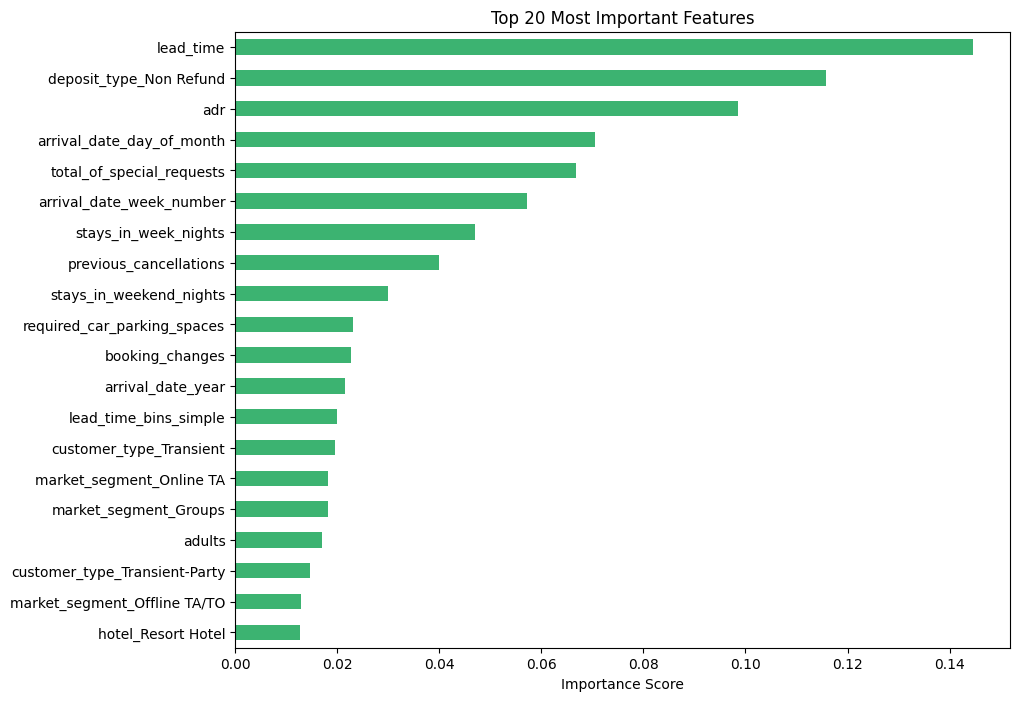


Top 10 Important Features:
lead_time                      0.144624
deposit_type_Non Refund        0.115845
adr                            0.098522
arrival_date_day_of_month      0.070458
total_of_special_requests      0.066825
arrival_date_week_number       0.057222
stays_in_week_nights           0.046995
previous_cancellations         0.040000
stays_in_weekend_nights        0.030052
required_car_parking_spaces    0.023184
dtype: float64


In [25]:
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
sorted_importance = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sorted_importance.head(20).plot(kind='barh', color='mediumseagreen')
plt.title('Top 20 Most Important Features')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

print("\nTop 10 Important Features:")
print(sorted_importance.head(10))

**Explanation:**

To understand which features were most influential in my Random Forest model's predictions, I accessed the `feature_importances_` attribute of the trained model. This gave me a score for each feature, indicating how much it contributed to the model's decision-making. I then organized these scores with their corresponding feature names using a pandas Series and sorted them to easily see the most important ones. Finally I printed the sorted list and created a bar plot to visually represent the top 20 features and their importance scores. This helped me identify the key factors the model considered when predicting hotel booking cancellations.

**Interpretation:**  
The most important features for predicting cancellations were lead_time, previous_cancellations, and deposit_type.  
This indicates guests who book far in advance or have previously cancelled are more likely to cancel again.  
Such insights can help hotels identify at-risk bookings early.


# CONCLUSION


---
The Random Forest model successfully predicts hotel booking cancellations with 86.33% accuracy.  
Through feature engineering, scaling, and data cleaning, the system effectively identifies key drivers of cancellations,  
providing actionable insights for hotel management. Future work could include testing other algorithms making it even higher accuracy.
